# Hierarchical Refinement with OTT‑JAX: Scalable Optimal Transport


### This notebook is a hands‑on tutorial showing how to implement Hierarchical Refinement using the low‑rank LRSinkhorn solver from ```OTT‑JAX```.

We experiment with the implementation of Hierachical Refinement based on the low-rank LRSinkhorn solver, proposed by [Halmos et al., 2025]([text](https://arxiv.org/pdf/2503.03025)). 
This algorithm to scalably compute a full-rank, bijective alignment between two equally-sized input datasets X and Y by solving a hierarchy of low-rank OT sub-problems. 

___

**1. Installation & Setup**
* Installing OTT‑JAX and dependencies  

**2. Generating Synthetic Data** 
* Creating two toy point clouds of equal cardinality,  each with a uniform mass
* Visualizing source and target  

**3. Low‑Rank partitions with LRSinkhorn**  
* Formulating the rank‑2 Sinkhorn problem  
* Using `Rank2Initializer` for deterministic splits  
* Inspecting the per‑scale soft‑clusters  

**4. Building Hierarchical Refinement (HiRef)**
* Recursive partitioning into sub‑blocks  
* Tracking original indices to recover a bijection  
* Putting it all together in a reusable function  

**5. Visualizing Multiscale Alignments**  
* Plotting co‑cluster assignments at each level  
* Drawing arrows for final Monge map 

## 1. Installation & Setup

* Installing OTT‑JAX and dependencies with requirements.txt

* Import of libraries: The proposed approach to implement HiRef algorithm use the OTT - JAX library and it is low rank Sinkhorn algorithm

* We strongly recommend to use the **```0.5.0``` version** which is the latest stable version of ```OTT-JAX```

In [8]:
#!pip install -r ../requirements.txt

In [ ]:

from functools import lru_cache
from typing import Callable

import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt
import ott
from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.initializers.linear.initializers_lr import Rank2Initializer
from ott.solvers.linear.sinkhorn_lr import LRSinkhorn



In [26]:
print("OTT_JAX version:", ott.__version__)

OTT_JAX version: 0.5.0


## 2. Generating Synthetic Data
* Standard version of HiRef algorithm requires points clouds to be both **same size** and with **uniform mass**

> Nombre paires de points ?


In [88]:
def create_points(rng, n, d):
    """
    Generate two toy point clouds of equal size and dimension.

    Parameters
    ----------
    rng : jax.random.PRNGKey
        A JAX random number generator key.
    n : int
        The number of points in each point cloud.
    d : int
        The dimensionality of each point.

    Returns
    -------
    x : jnp.ndarray of shape (n, d)
        Point cloud drawn from a standard normal distribution.
    y : jnp.ndarray of shape (n, d)
        Point cloud drawn from a uniform distribution on [4, 8).
    """
    rngs = jax.random.split(rng, 2)
    x = jax.random.normal(rngs[0], (n, d))
    y = jax.random.normal(rngs[1], (n, d))*20
    #y = jax.random.uniform(rngs[1], (n, d), minval=4, maxval=8)
    return x, y

In [89]:
rng = jax.random.key(4)
n, d = 320, 2
x, y = create_points(rng, n=n, d=d)

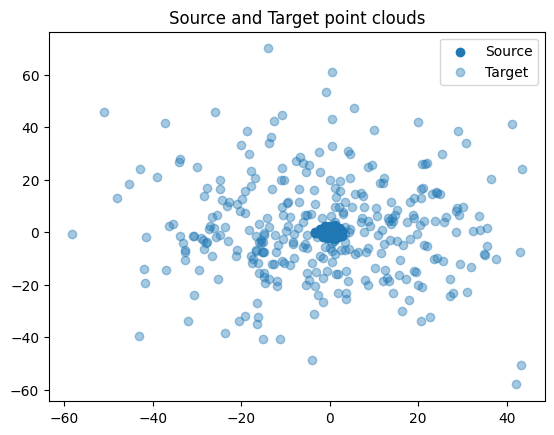

In [90]:
plt.scatter(x[:, 0], x[:, 1], label="Source", color="#1f77b4", alpha=1)
plt.scatter(y[:, 0], y[:, 1], label="Target", color="#1f77b4", alpha=0.4)
plt.legend()
plt.title("Source and Target point clouds")
plt.show()

## 3. Low-Rank Partitions with LRSinkhorn

In this section, we use **LRSinkhorn** (rank = 2) to split our point clouds \(X\) into two subsets. Proposition 3.1 guarantees the optimality of this partition.

---

### 3.1. Deterministic Initialization

We employ the **Rank2Initializer** (deterministic):  
> It manually constructs two equally-sized blocks (a trivial hard-clustering), then extends the partition to rank \(r\) via a simple analytical scheme.

---

### 3.2. Role of Regularization (`gamma`)

The parameter $\gamma$ controls the strength of entropic regularization (\(\varepsilon = 1/\gamma\)):

- **Small γ** (\(\varepsilon\) large): strong regularization → the transport plan is very diffuse and cluster sizes may deviate from uniform.  
- **Large γ** (\(\varepsilon\) small): regularization is nearly zero → the marginal constraint \(g=(½,½)\) is enforced **strictly**, so each cluster contains exactly half the points.

> **Tip:** To ensure two equally-sized clusters, choose **γ ≥ 100** (we typically use \(10^5\)).

---

### 3.3. JIT Compilation

To eliminate recompilation overhead, compile the solver **once** at the top of your notebook:

```python
from ott.solvers import low_rank
import jax

# 1) Initialize
init        = Rank2Initializer(rank=2)
base_solver = low_rank.LRSinkhorn(rank=2, initializer=init, gamma=1e5)

# 2) Single JIT compilation
solver_jit  = jax.jit(base_solver)


## Pour améliorer grandement le temps d'execution :
- Précompilé le solver une bonne fois pour toute en dehors de la fonction `low_rank_partition`
- Modifier la fonction pour qu'elle prenne en argument le solveur compilé 

> Cela devrait éviter que la fonction recompile le solveur à chaque partitions

## Comprendre l’influence de `gamma` sur la taille des partitions

Lorsque l’on utilise `LRSinkhorn(rank=2, γ=gamma)`, le paramètre `gamma` joue un rôle clé dans la **force de la régularisation entropique** et conditionne la répartition de la « masse » entre vos deux clusters.

---

### 1. Contrainte de marges uniformes

Dans la formulation low-rank OT, on fixe un vecteur de marges intermédiaires  
$$
g = \bigl(\tfrac1r, \tfrac1r, \dots, \tfrac1r\bigr)
$$
où \(r=2\) dans notre cas. Cette condition **uniformise** la répartition de la masse : chaque cluster doit capter exactement la moitié de la probabilité totale.  

---

### 2. Rôle de la régularisation entropique

On introduit une régularisation entropique paramétrée par  
$$
\varepsilon = \tfrac1\gamma.
$$  
- **γ petit** (\(\varepsilon\) grand) : régularisation forte → le plan de transport devient très diffus. Les poids de clusters peuvent s’écarter de \(g\), et les tailles de partitions deviennent inégales.  
- **γ grand** (\(\varepsilon\) petit) : régularisation quasi nulle → on approche le problème non entropique où la contrainte \(g\) est respectée **à la machine près**. Les deux clusters captent exactement 50 % de la masse chacun.  

---

### 3. Pourquoi choisir γ ≃ 100 000 ?

- Avec \(\gamma = 10^5\), on a \(\varepsilon = 10^{-5}\), **suffisamment petit** pour que l’effet entropique disparaisse dans la solution finale.  
- Ce compromis permet toujours une **convergence stable** du Sinkhorn, tout en garantissant que chaque cluster ait **exactement** la taille \(n/2\).  

---

### 4. En pratique dans votre code

```python
# Choix de gamma très élevé pour garantir des partitions équilibrées
base_solver = LRSinkhorn(
    rank=2,
    initializer=Rank2Initializer(rank=2),
    gamma=100_000  # ε = 1e-5 ⇒ régularisation négligeable
)
solver_jit = jax.jit(base_solver)

px, py, _ = solver_jit(ot_problem)
# px et py contiennent désormais deux partitions de même taille


In [14]:
# 1) Compilation unique
init        = Rank2Initializer(rank=2)
base_solver = LRSinkhorn(rank=2, initializer=init, gamma=1e5)
solver_jit  = jax.jit(base_solver)

### Role of `epsilon` in `PointCloud`

- **Entropic regularization scale**:  
  $\epsilon$ controls the smoothing of the OT kernel  
  $$
    K_{ij} = \exp\bigl(-C_{ij} / \epsilon\bigr).
  $$
  
- **Entropy–cost trade-off**:  

$$
\min_{P\in\Pi(a,b)} \langle C,P\rangle - \epsilon\,H(P).
$$
 
  - **Small ε** ⇒ sharp (almost sparse) coupling but slower convergence.  
  - **Large ε** ⇒ very smooth, diffuse coupling but faster convergence.

- **Practical choice**:  
  In HiRef we set  
  ```python
  epsilon = 1e-2
  gamma   = 1e5  # so that ε=1/gamma ≪ epsilon_geom


In [15]:
def low_rank_partition(x_block: jnp.ndarray,
                       y_block: jnp.ndarray,
                       solver: Callable = solver_jit):
    """
    Renvoie labels_x, labels_y, (Q,R,g) en appelant solver(ot_prob).
    """
    # 1) Créez le geometry correctement
    geom    = pointcloud.PointCloud(x_block, y_block, epsilon=1e-2)
    # 2) Instanciez le problème
    ot_prob = linear_problem.LinearProblem(geom)
    # 3) Lancez le solver compilé
    out     = solver(ot_prob)

    Q, R, g = out.q, out.r, out.g
    labels_x = jnp.argmax(Q, axis=1)
    labels_y = jnp.argmax(R, axis=1)
    return labels_x, labels_y, (Q, R, g)

In [16]:
# --- Exemple d’usage ---
partition_x, partition_y, matrice = low_rank_partition(x, y)

In [17]:
matrice

(Array([[3.12340888e-03, 3.06889725e-16],
        [0.00000000e+00, 3.12660076e-03],
        [7.97353834e-33, 3.12648877e-03],
        [3.12335370e-03, 0.00000000e+00],
        [3.12346546e-03, 0.00000000e+00],
        [3.12340888e-03, 0.00000000e+00],
        [0.00000000e+00, 3.12648877e-03],
        [0.00000000e+00, 3.12648877e-03],
        [0.00000000e+00, 3.12660076e-03],
        [3.12346546e-03, 0.00000000e+00],
        [3.12346546e-03, 0.00000000e+00],
        [0.00000000e+00, 3.12648877e-03],
        [0.00000000e+00, 3.12648877e-03],
        [3.12346546e-03, 0.00000000e+00],
        [3.12346546e-03, 0.00000000e+00],
        [0.00000000e+00, 3.12648877e-03],
        [0.00000000e+00, 3.12648877e-03],
        [3.12340888e-03, 0.00000000e+00],
        [3.12340888e-03, 0.00000000e+00],
        [3.12335370e-03, 0.00000000e+00],
        [0.00000000e+00, 3.12660076e-03],
        [3.12340888e-03, 2.71039726e-26],
        [0.00000000e+00, 3.12654558e-03],
        [3.12346546e-03, 3.3952064

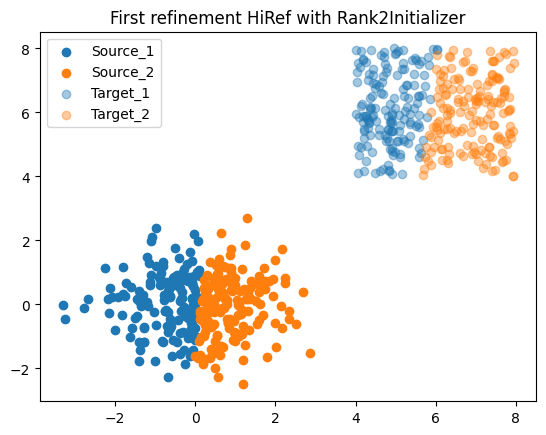

In [18]:
# Masques et affichage
mask_x1 = (partition_x == 0)
mask_x2 = ~mask_x1
mask_y1 = (partition_y == 0)
mask_y2 = ~mask_y1

import matplotlib.pyplot as plt
plt.scatter(x[mask_x1,0], x[mask_x1,1], color="#1f77b4", label="Source_1", alpha=1)
plt.scatter(x[mask_x2,0], x[mask_x2,1], color="#ff7f0e", label="Source_2", alpha=1)
plt.scatter(y[mask_y1,0], y[mask_y1,1], color="#1f77b4", label="Target_1", alpha=0.4)
plt.scatter(y[mask_y2,0], y[mask_y2,1], color="#ff7f0e", label="Target_2", alpha=0.4)
plt.legend(); plt.title("First refinement HiRef with Rank2Initializer"); plt.show()

## 4. Building Hierarchical Refinement (HiRef)



In [19]:
def hiref(x: jnp.ndarray,
          y: jnp.ndarray,
          x_idx: jnp.ndarray = None,
          y_idx: jnp.ndarray = None,
          rank: int = 2,
          base_size: int = 1):
    """
    Hierarchical Refinement: returns a list of (i,j) pairs
    where i,j are indices into the original datasets.
    """
    # 0) Initialize original indices
    if x_idx is None:
        x_idx = jnp.arange(x.shape[0])
    if y_idx is None:
        y_idx = jnp.arange(y.shape[0])

    n_x, n_y = x.shape[0], y.shape[0]

    # 1) Base case: both blocks are small enough
    if n_x <= base_size and n_y <= base_size:
        return [(int(x_idx[0]), int(y_idx[0]))]

    # 2) Low-rank partition (rank=2)
    lab_x, lab_y, _ = low_rank_partition(x, y, solver_jit)

    pairs = []
    # 3) Recurse on each cluster z
    for z in range(rank):
        mask_x    = (lab_x == z)
        mask_y    = (lab_y == z)
        x_sub     = x[mask_x]
        y_sub     = y[mask_y]

        # 3a) Skip any empty sub-block
        if x_sub.shape[0] == 0 or y_sub.shape[0] == 0:
            continue

        x_idx_sub = x_idx[mask_x]
        y_idx_sub = y_idx[mask_y]

        # 3b) Recurse
        pairs.extend(hiref(
            x_sub, y_sub,
            x_idx=x_idx_sub,
            y_idx=y_idx_sub,
            rank=rank,
            base_size=base_size
        ))

    return pairs

In [29]:
# Example usage:
pairs = hiref(x, y)

# Build the bijective transport matrix P ∈ {0,1}^{N×N}
N = x.shape[0]
P = jnp.zeros((N, N), dtype=jnp.int32)
for i, j in pairs:
    P = P.at[i, j].set(1)

# Verify each row and column sums to 1
# assert jnp.all(P.sum(axis=1) == 1)
# assert jnp.all(P.sum(axis=0) == 1)

print("Nombre de point transporté" : {P.sum(axis=1).sum()})

SyntaxError: invalid syntax (1174433527.py, line 14)

In [27]:
P.sum(axis=1).sum()
P.sum(axis=0).sum()

Array(314, dtype=int32)

In [28]:
C = jnp.sum((x[:, None, :] - y[None, :, :]) ** 2, axis=-1)
transport_cost = jnp.sum(P * C)
print("Total transport cost:", transport_cost)

Total transport cost: 22164.291


# 5. Visualizing Multiscale Alignments

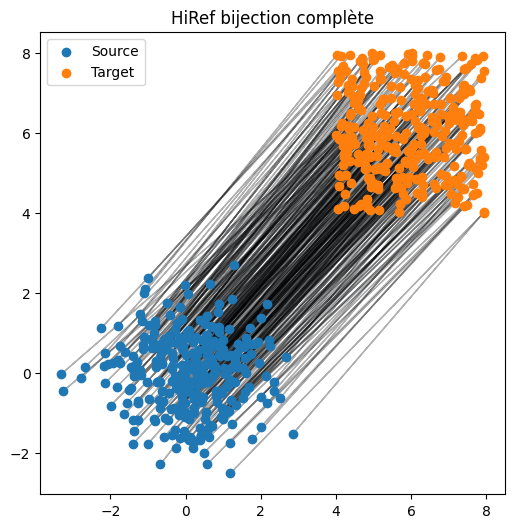

In [22]:
plt.figure(figsize=(6,6))
for i, j in pairs:
    plt.arrow(x[i,0], x[i,1],
              y[j,0] - x[i,0],
              y[j,1] - x[i,1],
              head_width=0.05, alpha=0.3, length_includes_head=True)
plt.scatter(x[:,0], x[:,1], c='C0', label='Source')
plt.scatter(y[:,0], y[:,1], c='C1', label='Target')
plt.legend(); plt.title("HiRef bijection complète"); plt.show()

> * 64 points en 1min8s

## 6. Next Step

1. Faire propre un fichier src (avec les fonctions hors du notebook)
2. Un peu mieux commenter (genre plus en mode tutorial) ce qui est déjà implémenter 
3. On utilise `rank_annealing.optimal_rank_schedule` (déjà implémenté) et on essaye de faire tourner Hiref avec ce **Rank-annealong Scedule**
4. On essaye de recoder notre propre fonction `rank_annealing.optimal_rank_schedule`

* Améliorer les explications du notebooks
    > Pourquoi gamma doit être grand? 

    > Choix initializer

    > Comparer performances (coût de transport, vistesse d'executions) avec d'autres algorithmes  
* Regarder s'il est possible d'améliorer l'efficacité de l'algorithme
* implémenter rank-annealing scheldule

# Autre

In [ ]:
"""

CA NE MARCHE PAS POUR LE MOMENT

"""


# 1) Fonction de compilation unique
def solver_compilation(rank: int = 2, gamma: float = 100000.0):
    """
    Initialise et compile une instance de LRSinkhorn pour un rang donné.
    Ne compile qu'une seule fois : sortie un callable JIT-compiled.
    """
    init        = Rank2Initializer(rank=rank)
    base_solver = LRSinkhorn(rank=rank, initializer=init, gamma=gamma)
    solver      = jax.jit(base_solver)
    return solver

# 2) Créez votre solver JIT une seule fois en début de programme
solver = solver_compilation(rank=2, gamma=100000.0)

def low_rank_partition(x_block, y_block):
    """
    Partie « bas rang » de la partition. 
    Appelle directement le solver compilé.
    """
    ot_prob = linear_problem.LinearProblem(x_block, y_block)
    out     = solver(ot_prob)
    Q, R    = out.q, out.r
    # argmax pour obtenir les labels 0/1
    lab_x = jax.numpy.argmax(Q, axis=1)
    lab_y = jax.numpy.argmax(R, axis=1)
    return lab_x, lab_y

def hiref(x, y):
    """
    Votre routine bijective, refactorisée pour n'appeler
    low_rank_partition qu'avec le solver déjà compilé.
    Utilise une pile Python au lieu de recursion JIT.
    """
    N       = x.shape[0]
    idx_x   = jax.numpy.arange(N)
    idx_y   = jax.numpy.arange(N)
    stack   = [(x, y, idx_x, idx_y)]
    pairs   = []

    while stack:
        x_blk, y_blk, ix, iy = stack.pop()
        if x_blk.shape[0] == 1:
            pairs.append((int(ix[0]), int(iy[0])))
            continue

        lab_x, lab_y = low_rank_partition(x_blk, y_blk)
        for z in (0, 1):
            mask_x = (lab_x == z)
            mask_y = (lab_y == z)
            stack.append((
                x_blk[mask_x], y_blk[mask_y],
                ix[mask_x],     iy[mask_y]
            ))

    return pairs

In [ ]:
pairs = hiref(x, y)

# 4) Construction de la matrice de transport bijective P ∈ {0,1}^{N×N}
N = x.shape[0]
P = jnp.zeros((N, N), dtype=jnp.int32)
for i, j in pairs:
    P = P.at[i, j].set(1)

# 5) Vérification
assert jnp.all(P.sum(axis=1) == 1)
assert jnp.all(P.sum(axis=0) == 1)

# IMPLEMENTATION

#### Rank annealing (code from the repository)

In [23]:
"""
Copyright (c) 2023, The Hierarchical Refinement Authors
All rights reserved.
"""

import operator
import functools
from functools import reduce


"""
Package for computing an optimal rank-annealing schedule for Hierarchical Refinement
"""

def optimal_rank_schedule(
        n: int,
        hierarchy_depth: int = 6,
        max_Q: int = int(2**10),
        max_rank: int = 16):
    """
    A function to compute the optimal rank-scheduler of refinement.
    Parameters
    ----------
    n: int
        Size of the input dataset -- cannot be a prime number
    hierarchy_depth: int
        Maximal permissible depth of the multi-scale hierarchy
    max_Q: int
        Maximal rank at terminal base case (before reducing the \leq max_Q rank coupling to a 1-1 alignment)
    max_rank: int
        Maximal rank at the intermediate steps of the rank-schedule
    """

    # Factoring out the max factor
    Q = max_factor_lX(n, max_Q)
    ndivQ = int(n / Q)

    # Compute partial rank schedule up to Q
    min_value, rank_schedule = min_sum_partial_products_with_factors(ndivQ, hierarchy_depth, max_rank)
    rank_schedule.sort()
    rank_schedule.append(Q)
    rank_schedule = [x for x in rank_schedule if x != 1]
    
    print(f'Optimized rank-annealing schedule: { rank_schedule }')
    
    assert functools.reduce(operator.mul, rank_schedule) == n, "Error! Rank-schedule does not factorize n!"
    
    return rank_schedule

def factors(n):
    # Return list of all factors of an integer
    return set(reduce(
        list.__add__,
        ([i, n//i] for i in range(1, int(n**0.5) + 1) if n % i == 0)))

def max_factor_lX(n, max_X):
    # Find max factor of n , such that max_factor \leq max_X
    factor_lst = factors(n)
    max_factor = 0
    for factor in factor_lst:
        if factor > max_factor and factor < max_X:
            max_factor = factor
    return max_factor

def min_sum_partial_products_with_factors(n, k, C):
    """
    Dynamic program to compute the rank-schedule, subject to a constraint of intermediates being \leq C

    Parameters
    ----------
    n: int
        The dataset size to be factored into a rank-scheduler. Assumed to be non-prime.
    k: int
        The depth of the hierarchy.
    C: int
        A constraint on the maximal intermediate rank across the hierarchy.
    
    """
    INF = float('inf')
    
    dp = [[INF]*(k+1) for _ in range(n+1)]
    choice = [[-1]*(k+1) for _ in range(n+1)]
    
    for d in range(1, n+1):
        if d <= C:
            dp[d][1] = d
            choice[d][1] = d
    
    for t in range(2, k+1):
        for d in range(1, n+1):
            if dp[d][t-1] == INF and t > 1:
                pass
            
            for r in range(1, min(C,d)+1):
                if d % r == 0:
                    candidate = r + r * dp[d // r][t-1]
                    if candidate < dp[d][t]:
                        dp[d][t] = candidate
                        choice[d][t] = r
    
    
    if dp[n][k] == INF:
        return None, []
    
    factors = []
    d_cur, t_cur = n, k
    
    while t_cur > 0:
        r_cur = choice[d_cur][t_cur]
        factors.append(r_cur)
        d_cur //= r_cur
        t_cur -= 1
    
    return dp[n][k], factors



#### Low Rank Parition

In [117]:
@functools.lru_cache(maxsize=10)
def get_initializer(rank):
    """
    This function is used to keep in cache the initializer initialized with the rank.
    """
    return Rank2Initializer(rank=rank)


@functools.lru_cache(maxsize=10)
def get_solver(rank):
    """
    This function is used to keep in cache the solver initialized with the rank.
    Thanks to jax.jit we can compile the function once and use it multiple times.
    """
    initializer = get_initializer(rank)
    solver = jax.jit(LRSinkhorn(
        rank=rank,
        initializer=initializer,
        gamma=1e5,
        min_iterations=20,
        threshold=1e-3
        ))
    
    return jax.jit(solver)

In [21]:
def low_rank_partition(
        x_block: jnp.ndarray,
        y_block: jnp.ndarray,
        solver: Callable         # Get the solver from the cache with get_solver
):
    """
    Renvoie labels_x, labels_y, (Q,R,g) en appelant solver(ot_prob).
    """
    # 1) Créez le geometry correctement
    geom = pointcloud.PointCloud(x_block, y_block, epsilon=1e-2)
    # 2) Instanciez le problème
    ot_prob = linear_problem.LinearProblem(geom)
    # 3) Lancez le solver compilé
    out = solver(ot_prob)

    Q, R, g = out.q, out.r, out.g

    labels_x = jnp.argmax(Q, axis=1)
    labels_y = jnp.argmax(R, axis=1)
    
    return labels_x, labels_y, (Q, R, g)

#### HiRef Algorithm

In [114]:
import time

def hiref_solver(
        X, 
        Y,
        rank_schedule: list = None,
        ):
    """
    HiRef - version itérative utilisant ott-jax et low-rank Sinkhorn.
    
    Args:
        X (jax array): Points source (n, d).
        Y (jax array): Points cible (n, d).
        rank_schedule (list of int): Liste des rangs à utiliser à chaque profondeur.

    Returns:
        list of tuples (xi, yj): Les correspondances finales.
    """

    n = X.shape[0]
    assert X.shape[0] == Y.shape[0], "X et Y doivent avoir la même taille."

    if rank_schedule is None:
        rank_schedule = optimal_rank_schedule(n=n)
        print(f"Optimized rank-annealing schedule: { rank_schedule }")

        
    correspondances = []
    start = time.time()
    stats = [(0, start, 1, 0)]  # (t, n_s, n_c, depth)

    # Chaque élément de la pile est (x_block, y_block, martingal X, martingal Y depth)
    stack = [(X, Y, 0)]
    t = 0

    while stack:

        x_block, y_block, depth = stack.pop()

        tempo = time.time() - start
        t += 1
        ns = len(stack)
        nc = len(correspondances)
        print(f"{t} : {depth} : [Stack size: {ns}] [Correspondences size: {nc}]", end="\r")

        
        # Condition de sortie de notre boucle while. On veut que tous les éléments finissent à cette étape
        if x_block.shape[0] == 1:
            correspondances.append((x_block[0], y_block[0]))
            continue

        # Définir le rang à utiliser
        rank = rank_schedule[depth] if depth < len(rank_schedule) else 2

        ### BLOC DE RESOLUTION DES SOUS CLUSTERS
        # Géométrie
        geom = pointcloud.PointCloud(x_block, y_block)

        # Problème de transport
        ot_prob = linear_problem.LinearProblem(geom)        # pour l'instant on reste avec des lois uniformes
  
        # Initialiseur + solveur Low-Rank Sinkhorn
        solver = get_solver(rank)
        
        # Résoudre le problème de transport
        out = solver(ot_prob)

        # Récupérer Q et R
        Q = out.q
        R = out.r

        q_labels = jnp.argmax(Q, axis=1)
        r_labels = jnp.argmax(R, axis=1)

        # Pour chaque cluster
        for label in range(rank):
            idx_x = jnp.where(q_labels == label)[0]
            idx_y = jnp.where(r_labels == label)[0]

            if len(idx_x) == 0 or len(idx_y) == 0:
                continue  # Ignore clusters vides

            x_subblock = x_block[idx_x]
            y_subblock = y_block[idx_y]

            # Ajouter le sous-bloc à la pile
            stack.append((x_subblock, y_subblock, depth + 1))
        
        stats.append((t, tempo, ns, nc))

    return correspondances, stats

# Exemple

## Création de points

In [106]:
rng = jax.random.key(4)
n, d = 128, 2
x, y = create_points(rng, n=n, d=d)

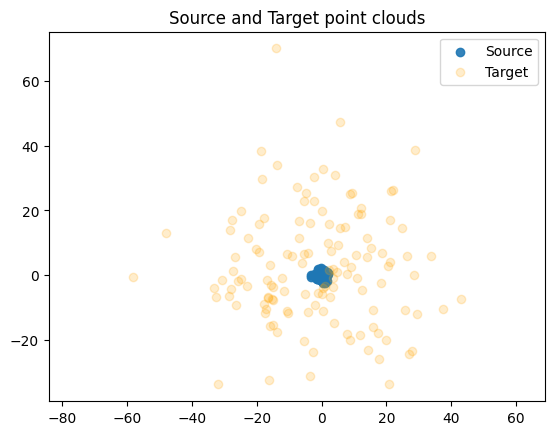

In [107]:
plt.scatter(x[:, 0], x[:, 1], label="Source", color="#1f77b4", alpha=0.9)   # bleu opaque
plt.scatter(y[:, 0], y[:, 1], label="Target", color="orange", alpha=0.2)   # orange transparent
plt.legend()
plt.title("Source and Target point clouds")
plt.axis("equal")
plt.show()


## défintion des ranks_schedule

In [108]:
rs1 = optimal_rank_schedule(n=n, hierarchy_depth=6, max_Q=int(n/20), max_rank=16)

Optimized rank-annealing schedule: [2, 16, 4]


In [109]:
rs2 = optimal_rank_schedule(n=n, hierarchy_depth=10, max_Q=int(2), max_rank=2)

Optimized rank-annealing schedule: [2, 2, 2, 2, 2, 2, 2]


In [118]:
corresp1, stats1 = hiref_solver(x, y, rank_schedule=rs1)

In [119]:
corresp2, stats2 = hiref_solver(x, y, rank_schedule=rs2)

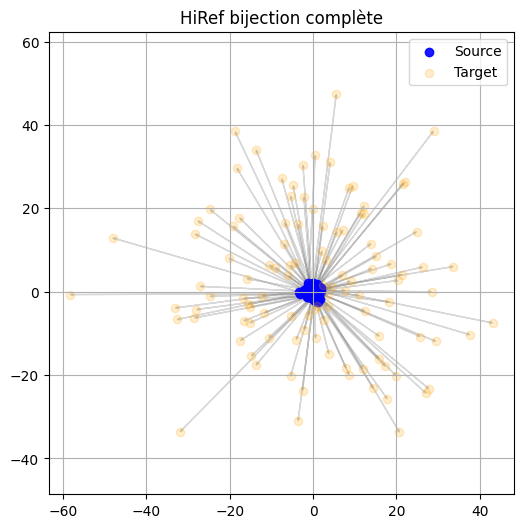

In [112]:
plt.figure(figsize=(6, 6))

for xi, yj in corresp1:
    plt.arrow(xi[0], xi[1],
              yj[0] - xi[0],
              yj[1] - xi[1],
              head_width=0.5, alpha=0.3, length_includes_head=True, color="gray")

# Affichage des nuages
plt.scatter([xi[0] for xi, _ in corresp1], [xi[1] for xi, _ in corresp1],
            color='blue', alpha=0.9, label='Source')

plt.scatter([yj[0] for _, yj in corresp1], [yj[1] for _, yj in corresp1],
            color='orange', alpha=0.2, label='Target')

plt.legend()
plt.title("HiRef bijection complète")
plt.axis("equal")
plt.grid(True)
plt.show()
